## Bayesian Updating in diagnostic test Models
In this notebook we will demonstrate how Bayes'theorem applies to medical diagnostic testing,
showing how prior beliefs update to posterior probabilities given test results

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

## Key concepts
- **Prior P(D)**: Disease prevalence (propability of disease before testing)
- **Sensitivty P(+|D)**: True positive rate (probability of positive test given disease)
- **Specifcity P(-|not(D))**: true negative rate (probability of negative test given no disease)
- **Posterior P(D|+)**: Probability of a desease given the test is positive

In [3]:
def bayes_diagnostic(prior, sensitivity, specificity, test_positive=True):
    if test_positive:
        # P(D|+) = P(+|D)P(D) / [P(+|D)P(D) + P(+|no(D))P(no(D))] 
        likelihood_desease = sensitivity
        likelihood_no_desease = 1 - specificity #false positive rate
    else:
        # P(D|-) = P(-|D)P(D) / [P(-|D)P(D) + P(-|no(D))P(no(D))]
        likelihood_desease = 1 - sensitivity
        likelihood_no_desease = specificity
    numerator = likelihood_desease*prior
    denominator = numerator + likelihood_no_desease*(1-prior)

    return numerator/denominator

## Example : Covid-19 Rapid test
Suppose a rapid antigen test has:
- Sensitivity: 85% (detects 85% of true cases)
- Specificity: 99% (correctly indentifies 99% of non-cases)
- Prevalence: 2% (during moderate outbreak)

In [4]:
prevalence = 0.02
sensitivity = 0.85
specificity = 0.99

posterior_positive = bayes_diagnostic(prevalence, sensitivity, specificity, test_positive=True)
posterior_negative = bayes_diagnostic(prevalence, sensitivity, specificity, test_positive=False)

print(f"Prior probability of disease: {prevalence:.1%}")
print("\nIf test is Positive")
print(f"Posterior P(Disease|+): {posterior_positive:.1%}")
print("\nIf test is Negative")
print(f"Posterior P(Disease|-): {posterior_negative:.1%}")

Prior probability of disease: 2.0%

If test is Positive
Posterior P(Disease|+): 63.4%

If test is Negative
Posterior P(Disease|-): 0.3%


## Sequential Bayesian Updating
when we perform multiple independent tests, each posterior becomes the prior for the next update

In [5]:
def sequential_update(prior, sensitivity, specificity, test_results):
    # update probability sequentially given multiple test results
    history = [prior]
    current_prior = prior

    for result in test_results:
        posterior = bayes_diagnostic(current_prior, sensitivity, specificity, result)
        history.append(posterior)
        current_prior = posterior

    return history

### Scenario: Two positive tests followed by one negative

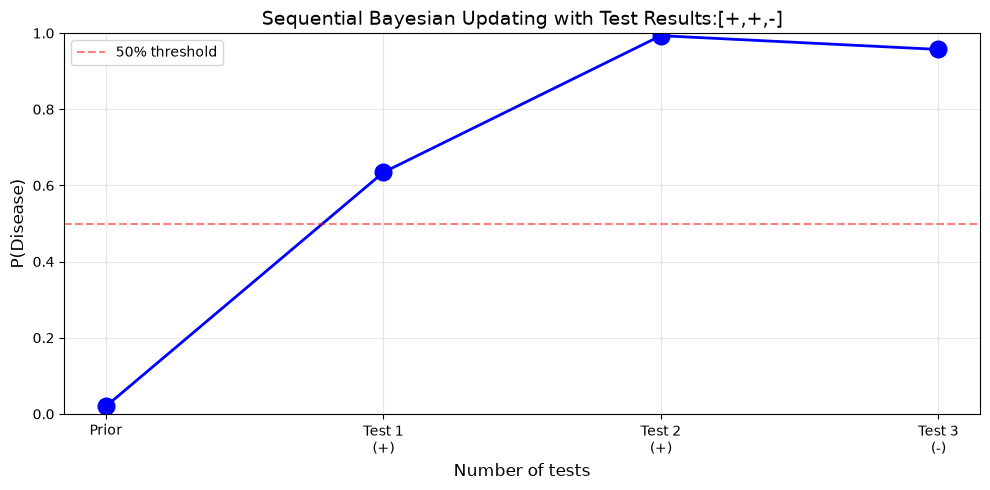


Posterior probabilities
Prior: 0.0200
After test 1 (+): 0.6343
After test 2 (+): 0.9933
After test 3 (-): 0.9572


In [6]:
test_results = [True, True, False]
history = sequential_update(prevalence, sensitivity, specificity, test_results)

plt.figure(figsize=(10,5))
plt.plot(range(len(history)), history, 'bo-', markersize=12, linewidth=2)
plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.5, label='50% threshold')
plt.xlabel('Number of tests', fontsize=12)
plt.ylabel('P(Disease)', fontsize=12)
plt.title('Sequential Bayesian Updating with Test Results:[+,+,-]', fontsize=14)
plt.xticks(range(len(history)), ['Prior'] + [f'Test {i+1}\n({["-", "+"][r]})' for i, r in enumerate(test_results)])
plt.ylim(0,1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("\nPosterior probabilities")
for i,p in enumerate(history):
    if i == 0:
        print(f"Prior: {p:.4f}")
    else:
        print(f"After test {i} ({'+' if test_results[i-1] else '-'}): {p:.4f}")

## The Base Rate Fallacy

Even with a highly accurate test, a positive result may not mean high probability
of disease when the disease is rare. This is the **base rate fallacy**

In [7]:
rare_prevalence = 0.001
high_sensitivity = 0.99
high_specificity = 0.99

posterior_rare = bayes_diagnostic(rare_prevalence, high_sensitivity, high_specificity, True)

print("base Rate Fallacy Demonstration")
print(f"\nRare disease prevalence: {rare_prevalence:.2%} (1 in 1000)")
print(f"Test sensitivity: {high_sensitivity:.0%}")
print(f"Test specificity: {high_specificity:.0%}")
print(f"\nProbability of disease given positive test: {posterior_rare:.1%}")

base Rate Fallacy Demonstration

Rare disease prevalence: 0.10% (1 in 1000)
Test sensitivity: 99%
Test specificity: 99%

Probability of disease given positive test: 9.0%


So as we can see in the result, despite 99% accuracy, most positive tests are False Positives, let's visualize it :

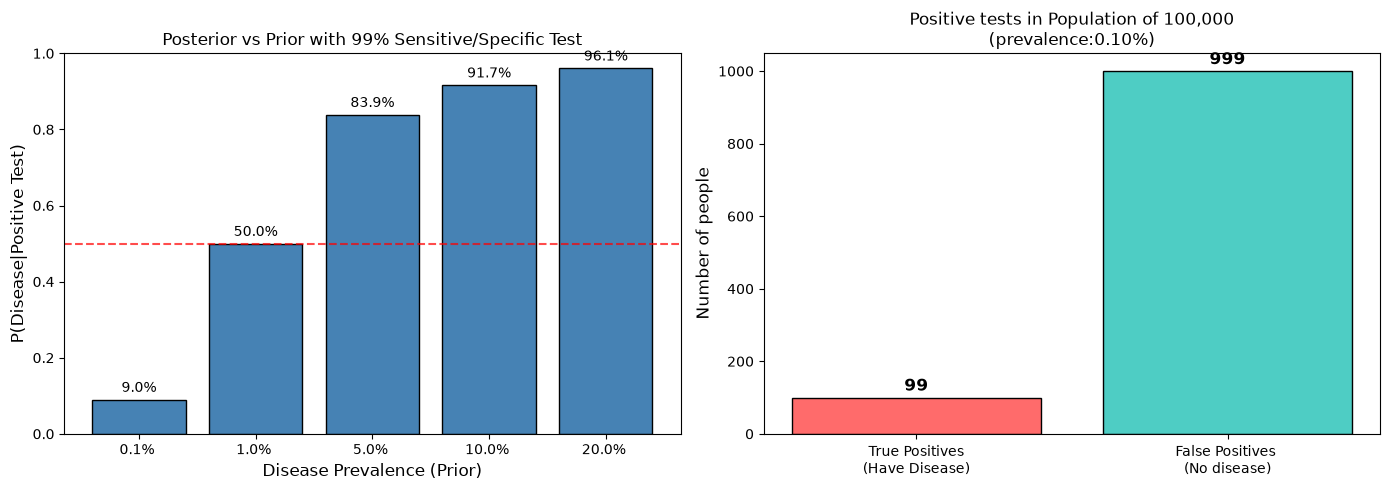

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

#Left : population breakdown
prevalences = [0.001, 0.01, 0.05, 0.1, 0.2]
posteriors = [bayes_diagnostic(p, 0.99, 0.99, True) for p in prevalences]

axes[0].bar(range(len(prevalences)), posteriors, color = 'steelblue', edgecolor = 'black')
axes[0].set_xticks(range(len(prevalences)))
axes[0].set_xticklabels([f'{p:.1%} 'for p in prevalences])
axes[0].set_xlabel('Disease Prevalence (Prior)', fontsize=12)
axes[0].set_ylabel('P(Disease|Positive Test)', fontsize=12)
axes[0].set_title('Posterior vs Prior with 99% Sensitive/Specific Test', fontsize=12)
axes[0].axhline(y=0.5, color='r', linestyle='--', alpha=0.7)
axes[0].set_ylim(0,1)
for i,v in enumerate(posteriors):
    axes[0].text(i,v+0.02,f'{v:.1%}', ha='center', fontsize=10)

#Right: True vs False positives for rare disease
population = 100000
diseased = int(population*rare_prevalence)
healthy = population - diseased

true_positives = diseased*high_sensitivity
false_positives = healthy*(1-high_specificity)

labels = ['True Positives\n(Have Disease)', 'False Positives \n(No disease)']
sizes = [true_positives, false_positives]
colors=['#ff6b6b', '#4ecdc4']

axes[1].bar(labels, sizes, color=colors, edgecolor='black')
axes[1].set_ylabel('Number of people', fontsize=12)
axes[1].set_title(f'Positive tests in Population of {population:,}\n(prevalence:{rare_prevalence:.2%})', fontsize=12)
for i,v in enumerate(sizes):
    axes[1].text(i, v+20, f'{int(v):,}', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


## Beta Distribution Prior (continuous bayesian updating)
Instead of a point estimate, we can model uncertainty about prevalence using a Beta distribution

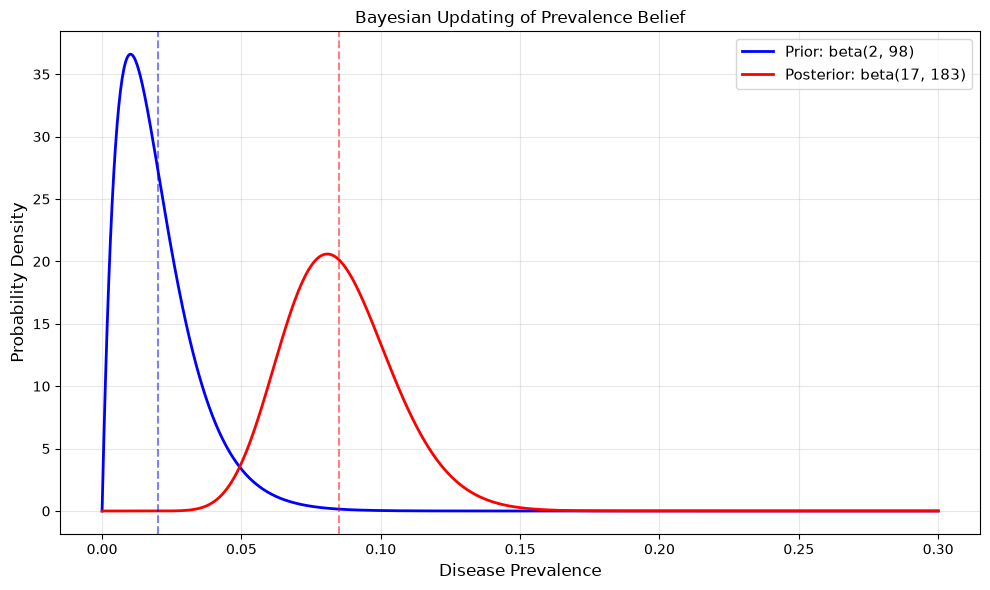

Prior mean: 2.00%, 95% CI:[0.25%, 5.50%]
Posterior mean: 8.50%, 95% CI:[5.06%, 12.73%]


In [11]:
def beta_update(alpha_prior, beta_prior, positive_tests, negative_tests):
    # updating beta distribution with test results
    alpha_post = alpha_prior + positive_tests
    beta_post = beta_prior + negative_tests
    return alpha_post, beta_post

# starting with weak prior
alpha_prior, beta_prior = 2, 98

# observe 15 positive and 85 negative in a sample
pos_observed, neg_observed = 15, 85

alpha_post, beta_post = beta_update(alpha_prior, beta_prior, pos_observed, neg_observed)

# Plot
x = np.linspace(0, 0.3, 1000)
prior_dist = stats.beta(alpha_prior, beta_prior)
post_dist = stats.beta(alpha_post, beta_post)

plt.figure(figsize=(10,6))
plt.plot(x, prior_dist.pdf(x), 'b-', linewidth=2, label = f'Prior: beta({alpha_prior}, {beta_prior})')
plt.plot(x, post_dist.pdf(x), 'r-', linewidth=2, label = f'Posterior: beta({alpha_post}, {beta_post})')
plt.axvline(prior_dist.mean(), color='b', linestyle='--', alpha=0.5)
plt.axvline(post_dist.mean(), color='r', linestyle='--', alpha=0.5)
plt.xlabel('Disease Prevalence', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.title('Bayesian Updating of Prevalence Belief', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Prior mean: {prior_dist.mean():.2%}, 95% CI:[{prior_dist.ppf(0.025):.2%}, {prior_dist.ppf(0.975):.2%}]")
print(f"Posterior mean: {post_dist.mean():.2%}, 95% CI:[{post_dist.ppf(0.025):.2%}, {post_dist.ppf(0.975):.2%}]")





## Key takeways
 1. **Bayes Theorem**: converts prior probabiltiy to posterior given evidence
 2. **Base Rate matters**: high accuracy tests can still yield mostly false positive for rare diseases
 3. **Sequantial Updating**: Each test result refines our belief
 4. **Beta Distributions**: allow continous modeling of uncertainty about prevalence